In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

In [47]:
train_images = np.load('archive/train_images.npy')
train_labels = np.load('archive/train_labels.npy')
test_images = np.load('archive/test_images.npy')
test_labels = np.load('archive/test_labels.npy')

In [48]:
train_images.shape

(60000, 28, 28)

In [49]:
train_images[0].shape

(28, 28)

In [50]:
test_images.shape

(10000, 28, 28)

In [51]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [52]:
train_labels[0]

5

In [53]:
features = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0]
])

labels = torch.tensor([0, 1, 0])

dataset = TensorDataset(features, labels)
dataset[1]

(tensor([3., 4.]), tensor(1))

In [54]:
dataloader = DataLoader( dataset, batch_size = 2, shuffle = True )

for batch in dataloader:
    features, labels = batch
    print(features, labels)

tensor([[1., 2.],
        [3., 4.]]) tensor([0, 1])
tensor([[5., 6.]]) tensor([0])


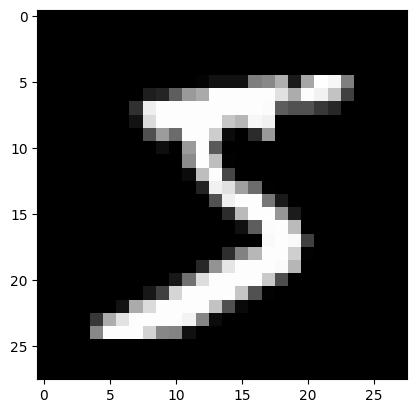

In [55]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0], cmap='gray')
plt.show()

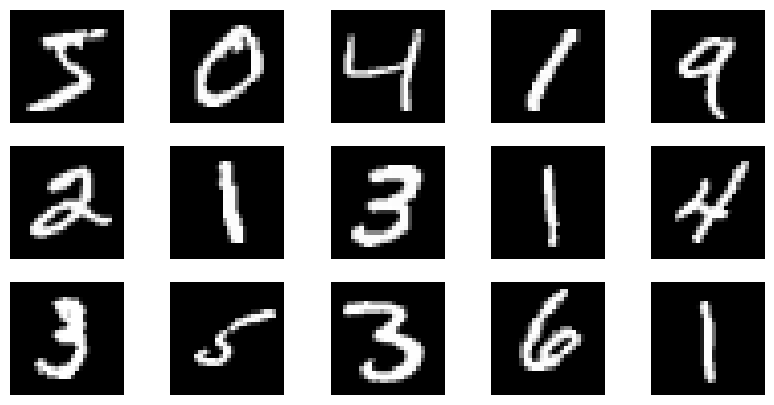

In [56]:
fig, axes = plt.subplots(3, 5, figsize=(10, 5))

axes = axes.flatten()

for i in range(15):
   axes[i].imshow(train_images[i], cmap='gray')
   axes[i].axis('off')
   
plt.show()

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size=0.1, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(test_images, dtype=torch.float32)
y_test = torch.tensor(test_labels, dtype=torch.long)

In [58]:
X_train.shape

torch.Size([54000, 28, 28])

In [59]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [60]:
class DigitalClassificationModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, features):
        output = self.network(features)
        return output

In [61]:
model = DigitalClassificationModel(input_size=28*28, num_classes=10)
print(model)

DigitalClassificationModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [66]:
epochs = 20

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
    
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {running_loss:.4f} | Validation Loss: {val_loss:.4f}")

Epoch 1/20 | Train Loss: 0.2121 | Validation Loss: 8.3047
Epoch 2/20 | Train Loss: 0.1963 | Validation Loss: 8.3289
Epoch 3/20 | Train Loss: 0.1804 | Validation Loss: 8.4108
Epoch 4/20 | Train Loss: 0.1682 | Validation Loss: 8.4995
Epoch 5/20 | Train Loss: 0.1564 | Validation Loss: 8.5464
Epoch 6/20 | Train Loss: 0.1480 | Validation Loss: 8.5717
Epoch 7/20 | Train Loss: 0.1392 | Validation Loss: 8.7095
Epoch 8/20 | Train Loss: 0.1316 | Validation Loss: 8.6858
Epoch 9/20 | Train Loss: 0.1240 | Validation Loss: 8.8049
Epoch 10/20 | Train Loss: 0.1185 | Validation Loss: 8.7189
Epoch 11/20 | Train Loss: 0.1130 | Validation Loss: 8.9327
Epoch 12/20 | Train Loss: 0.1076 | Validation Loss: 8.9046
Epoch 13/20 | Train Loss: 0.1030 | Validation Loss: 8.9386
Epoch 14/20 | Train Loss: 0.0984 | Validation Loss: 8.9589
Epoch 15/20 | Train Loss: 0.0944 | Validation Loss: 8.9361
Epoch 16/20 | Train Loss: 0.0907 | Validation Loss: 9.0187
Epoch 17/20 | Train Loss: 0.0878 | Validation Loss: 9.1554
Epoch 

In [67]:
with torch.no_grad():
  y_pred_prob = model(X_test)


y_pred_prob.shape

y_pred = torch.argmax(y_pred_prob ,dim = 1)


print("Prediction", y_pred[:10])
print("Actual : ,", y_test[:10])

Prediction tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
Actual : , tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


In [68]:
epochs = 20

for epoch in range(epochs):
    # --- ১. Training Phase ---
    model.train()  # মডেলকে ট্রেনিং মোডে নেওয়া
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy হিসাব:
        _, predicted = torch.max(outputs, 1)        # সর্বোচ্চ স্কোরের ক্লাস ইনডেক্স বের করা
        total_train += labels.size(0)               # মোট ছবির সংখ্যা যোগ করা
        correct_train += (predicted == labels).sum().item() # কয়টি সঠিক হয়েছে যোগ করা

    train_acc = (correct_train / total_train) * 100

    # --- ২. Validation Phase ---
    model.eval()  # মডেলকে ইভ্যালুয়েশন মোডে নেওয়া
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy হিসাব:
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = (correct_val / total_val) * 100

    # --- ৩. রেজাল্ট প্রিন্ট ---
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0973 | Val Acc: 98.08%
Epoch 2/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0972 | Val Acc: 98.08%
Epoch 3/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0981 | Val Acc: 98.07%
Epoch 4/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0987 | Val Acc: 98.07%
Epoch 5/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0988 | Val Acc: 98.07%
Epoch 6/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0988 | Val Acc: 98.10%
Epoch 7/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0992 | Val Acc: 98.08%
Epoch 8/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0989 | Val Acc: 98.12%
Epoch 9/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0994 | Val Acc: 98.08%
Epoch 10/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0999 | Val Acc: 98.10%
Epoch 11/20 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0999 | Val Acc: 98.08%
Epoch 12